<a href="https://colab.research.google.com/github/ArJuNSinGhhhhhh/aiproject-/blob/main/lab_3_healthcare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.1 MB/s eta 0:00:00
(768, 9)
Real NaN values: 0   <- looks clean, but...

Impossible zeros per column:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64
Duplicates removed: 0
Missing after cleaning: 0
Outcome
No diabetes    500
Diabetes       268
Name: count, dtype: int64
Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64 
-> class imbalance (~65/35)


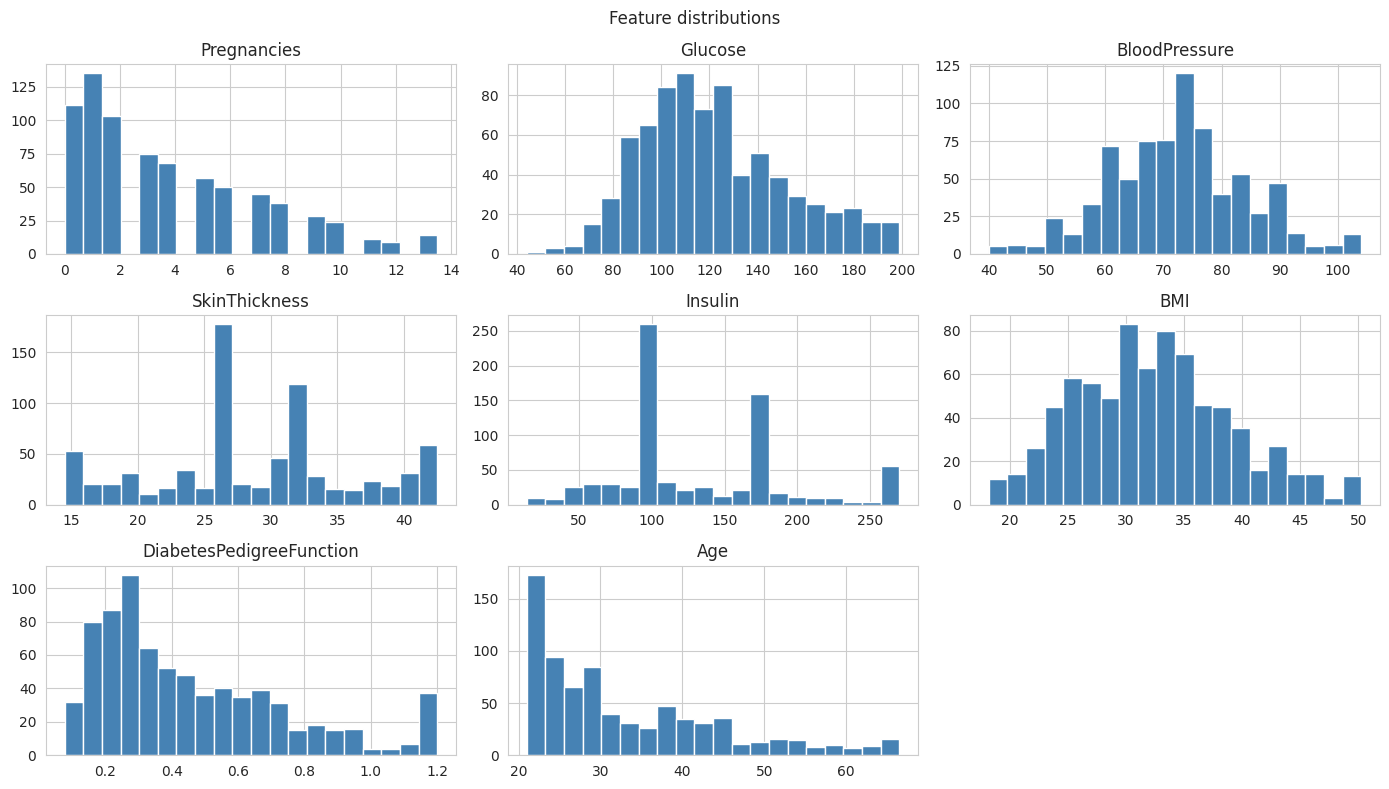

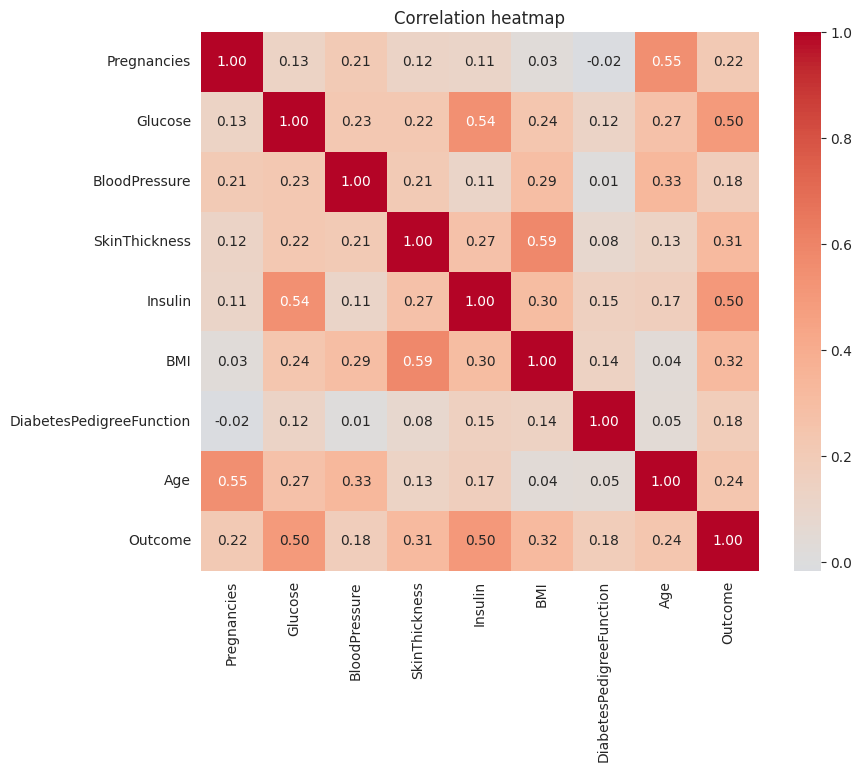

[t-test] mean glucose diabetic = 142.3, non-diabetic = 110.6
         t = 14.99, p-value = 8.30e-42
         -> Reject H0: glucose differs significantly
Outcome              0    1
BMI_cat                    
Normal(<25)        105    7
Overweight(25-30)  136   44
Obese(30+)         259  217

[chi-square] chi2 = 73.06, dof = 2, p-value = 1.36e-16
            -> Reject H0: BMI category is associated with diabetes
[ANOVA] F = 20.05, p-value = 1.62e-12
        -> Reject H0: glucose differs across age groups


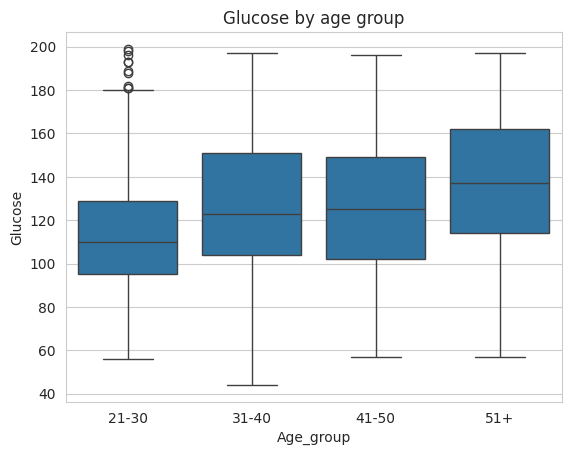

Shape after feature engineering: (768, 16)
Glucose_BMI              292.3
Insulin                  256.3
Glucose                  249.9
BMI                       85.3
SkinThickness             83.8
BMI_cat_Obese(30+)        68.5
Insulin_Glucose_ratio     62.9
Age                       47.9
Pregnancies               39.1
Age_group_41-50           28.5
dtype: float64

Selected features: ['Glucose_BMI', 'Insulin', 'Glucose', 'BMI', 'SkinThickness', 'BMI_cat_Obese(30+)', 'Insulin_Glucose_ratio', 'Age']
Train class counts BEFORE: {0: 400, 1: 214}
Train class counts AFTER : {1: 400, 0: 400}
Model-ready shapes -> (800, 8) (154, 8)


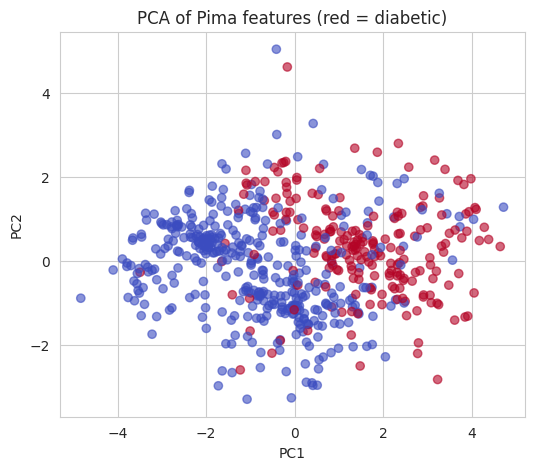

Variance explained: [0.459 0.175]
(2357, 6)
BEFORE: CC:, Confusion and slurred speech.,HX , (primarily obtained from boyfriend): This 31 y/o RHF experienced a "flu-like illness 6-8 weeks prior to presentation. 3-4 weeks prior to presentation, she was f
AFTER : CC:, Confusion and slurred speech.,HX , (primarily obtained from boyfriend): This 31 y/o RHF experienced a "flu-like illness 6-8 weeks prior to presentation. 3-4 weeks prior to presentation, she was f


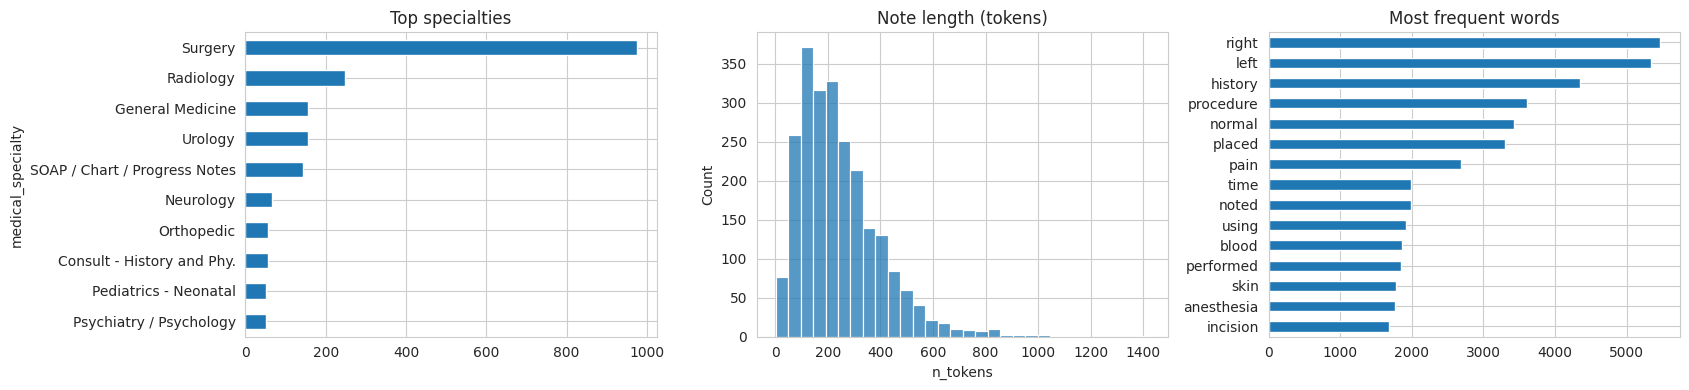

TF-IDF matrix: (2357, 3000)
Token-sequence tensor: (2357, 200)
Top terms for ['Surgery', 'Radiology', 'General Medicine']
['allergies' 'daily' 'denies' 'discharge' 'exam' 'heent' 'history'
 'illness' 'images' 'medical history' 'past' 'past medical'
 'review systems' 'systems' 'unremarkable']
original : ['subjective', 'year', 'old', 'white', 'female', 'presents', 'complaint', 'allergies', 'used', 'allergies', 'lived', 'seattle']
deleted  : ['subjective', 'old', 'white', 'female', 'presents', 'complaint', 'used', 'lived', 'seattle', 'worse', 'past', 'tried']
swapped  : ['subjective', 'year', 'old', 'white', 'female', 'presents', 'complaint', 'allergies', 'used', 'allergies', 'lived', 'seattle']
Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Loaded REAL X-rays: 120
Images: 120 | class counts: {0: 60, 1: 60}
Full train-set counts: {'NORMAL': 2682, 'PNEUMONIA': 7750}

Most common original sizes: [((1488, 1275), 2), ((1666, 1537), 2), ((2090, 1932), 1)]
Original c

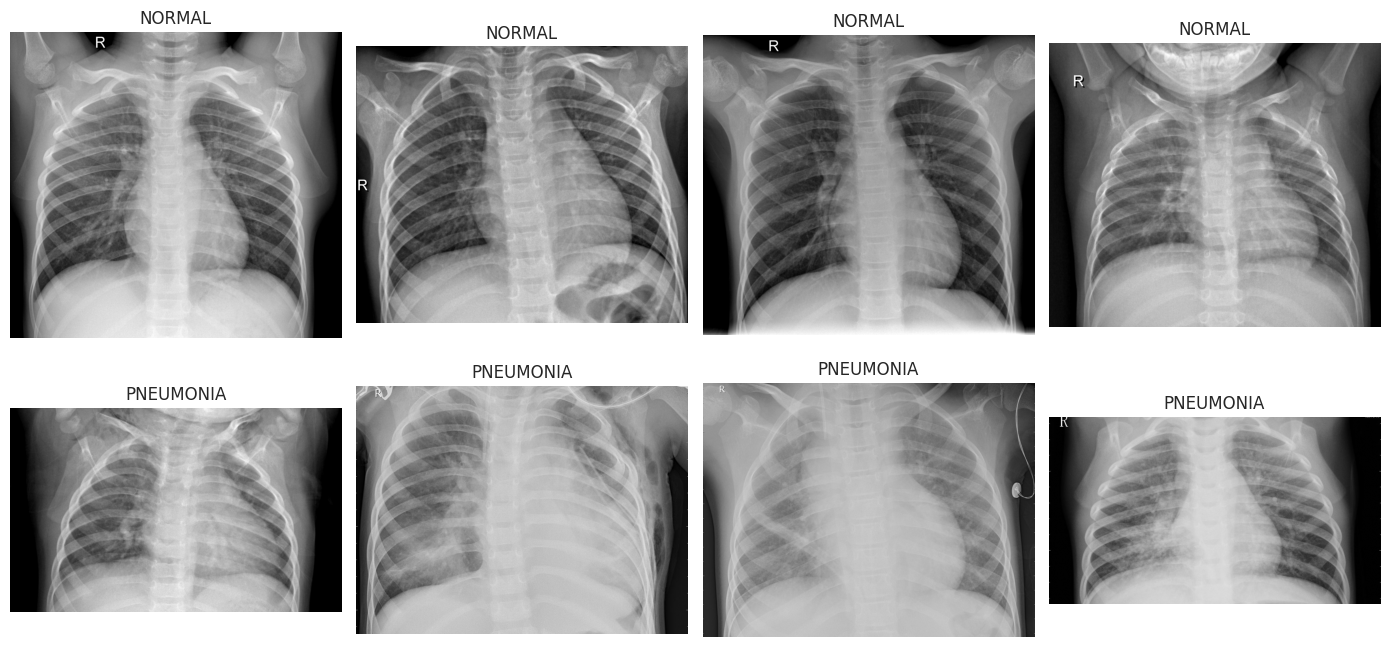

BEFORE anonymization: {'PatientName': 'John Doe', 'PatientID': '12345'}
AFTER anonymization : {}
Image tensor: (120, 128, 128, 1) | min/max: 0.007843138 1.0


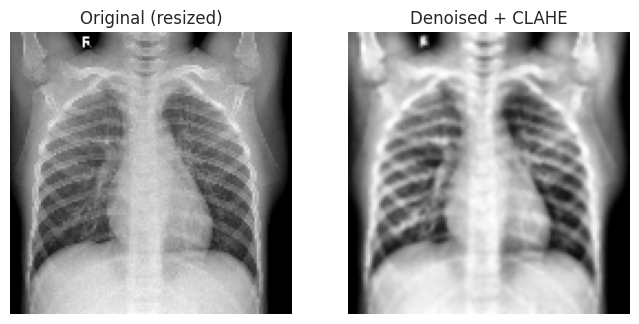

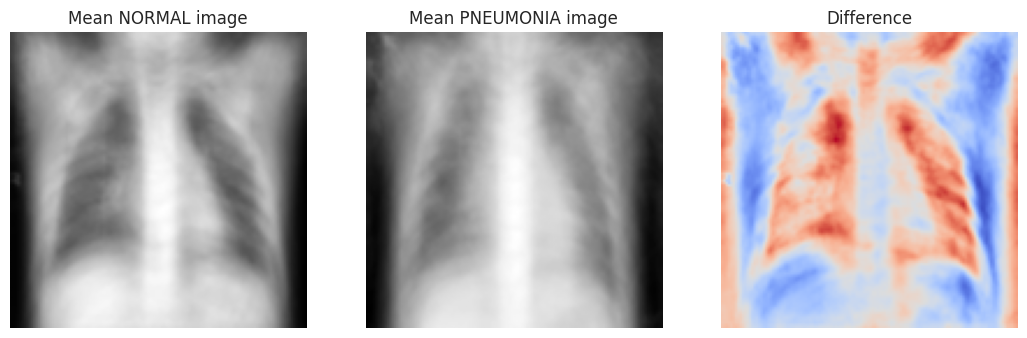

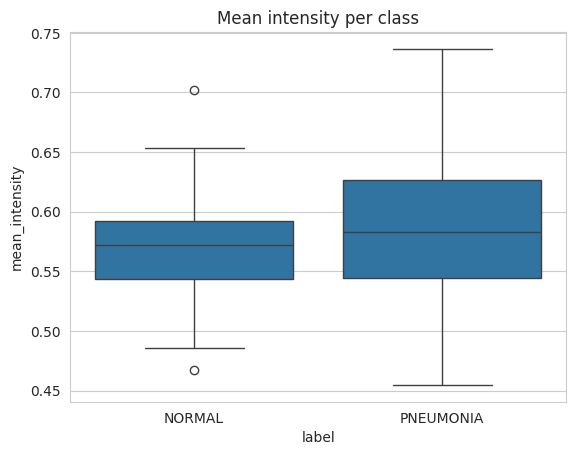

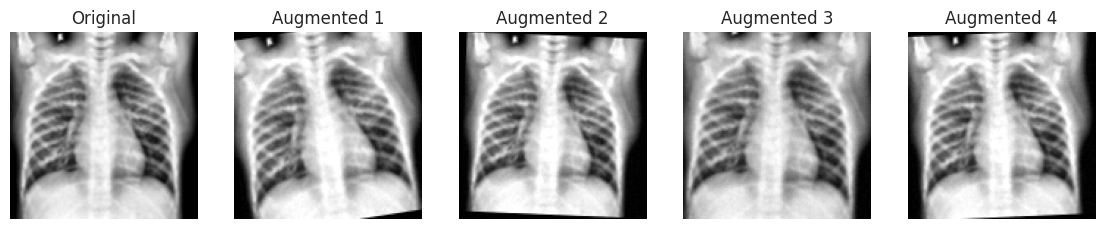

Train: (96, 128, 128, 1) | Val: (24, 128, 128, 1) | class weights: {0: 1.0, 1: 1.0}
Channels: ['MLII', 'V5'] | units: ['mV', 'mV']
Sampling rate: 360 Hz | samples: 108000 | duration: 300 s
NaN samples: 0 | flat-line check (std): 0.176
Annotation symbols: {'+': 1, 'N': 367, 'A': 4}


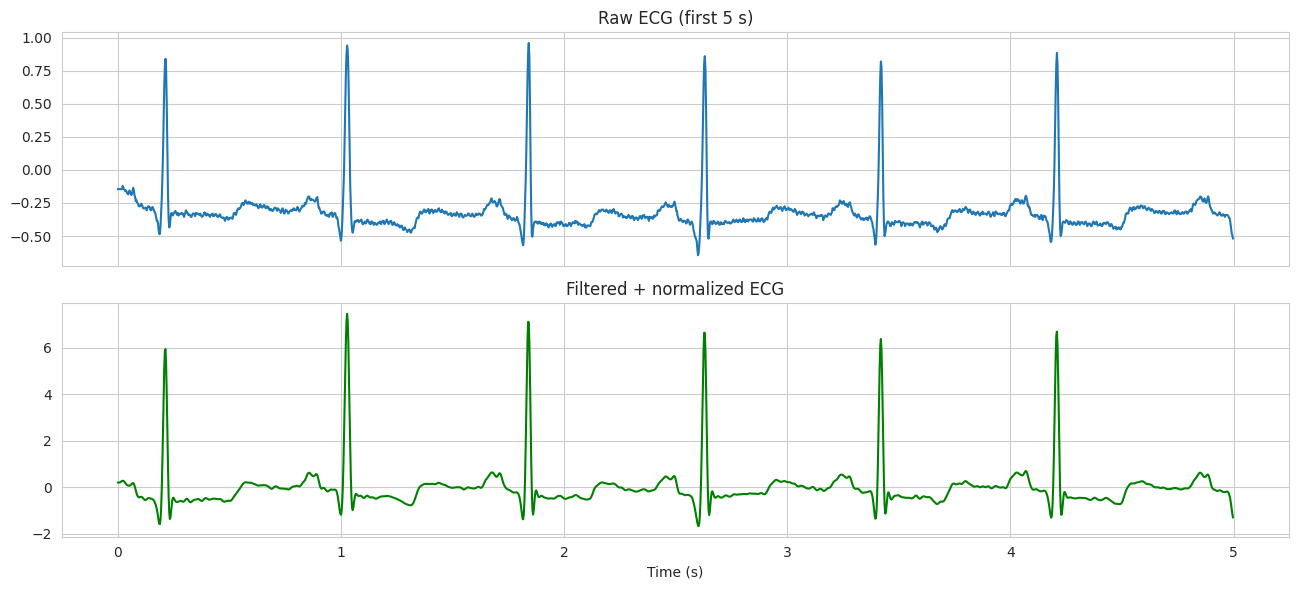

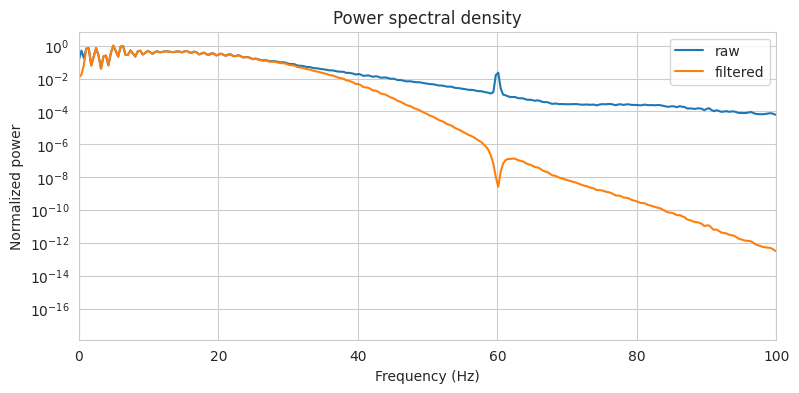

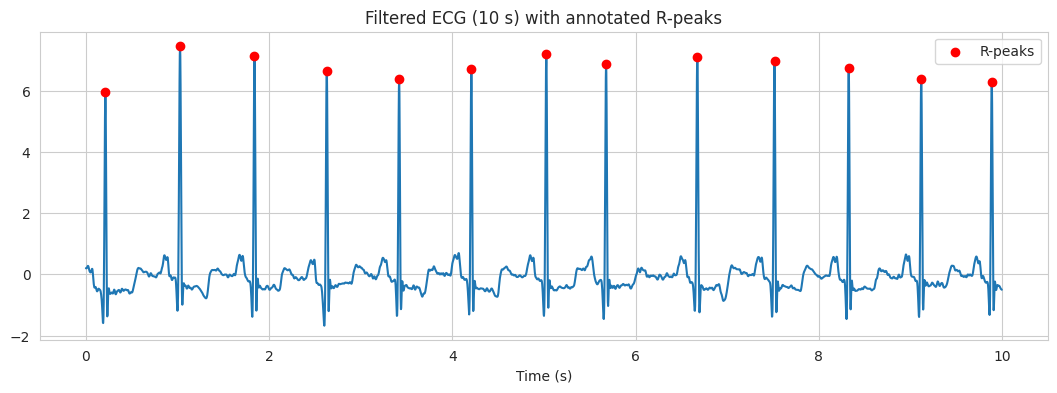

Mean heart rate : 74.2 bpm
SDNN  (overall variability) : 38.5 ms
RMSSD (beat-to-beat)        : 55.7 ms
pNN50                       : 6.8 %
Beat windows: (369, 200)
Class distribution (imbalanced!): {'N': 365, 'S': 4}


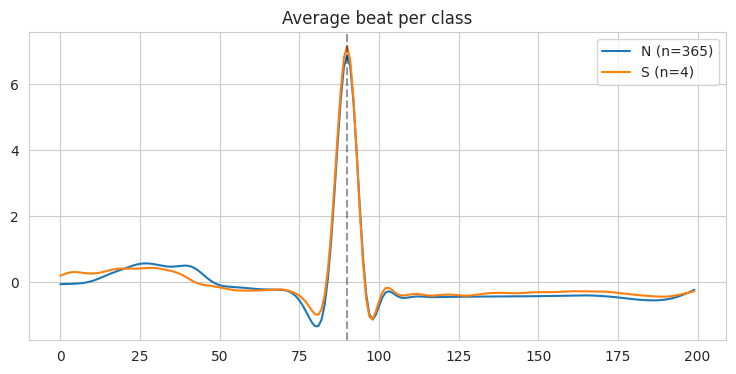

Feature ranking (ANOVA F-score):
pre_RR         220.1
RR_ratio       195.5
post_RR         83.9
R_amplitude      1.2
beat_max         1.1
beat_min         0.9
beat_std         0.1
energy           0.1
dtype: float64
After augmentation: {'N': 365, 'S': 365}
Model-ready ECG tensor: (730, 200, 1)


In [1]:
# Lab Assignment 3 - copy each CELL block into a separate Colab cell (top to bottom)


# # Lab Assignment 3 — Data Acquisition, Cleaning, Preprocessing & Analysis
# **CSET343 – AI in Healthcare** | Parts: A) Tabular (Pima Diabetes) · B) Text (MTSamples) · C) Image (Chest X-ray) · D) Signal (MIT-BIH ECG)
#
# Run all cells top to bottom. Everything downloads automatically and is kept small so it runs fast.
# Each part has a fallback (built-in sample data) so the notebook never crashes if a download fails.


# ===== CELL 1 =====
!pip install -q wfdb kagglehub


# ===== CELL 2 =====
import warnings; warnings.filterwarnings("ignore")
import os, re, glob, random
from collections import Counter
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, chi2
from sklearn.decomposition import PCA
from sklearn.utils import resample
sns.set_style("whitegrid")
np.random.seed(42); random.seed(42)

def load_csv(url, **kw):
    """Read a CSV from a URL; if download fails, ask the user to upload the file."""
    try:
        opts = {"User-Agent": "Mozilla/5.0"} if str(url).startswith("http") else None
        return pd.read_csv(url, storage_options=opts, **kw)
    except Exception as e:
        print("Download failed:", e, "\nPlease upload the CSV file manually:")
        from google.colab import files
        up = files.upload()
        return pd.read_csv(next(iter(up)), **kw)


# ---
# # PART A — Tabular Data: Pima Indians Diabetes


# ===== CELL 3 =====
# A1. Acquire (same Pima dataset, GitHub mirror -> no Kaggle login needed)
cols = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin",
        "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
URL_PIMA = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
pima = load_csv(URL_PIMA, header=None, names=cols)
print(pima.shape)
pima.head()


# ===== CELL 4 =====
# A2. Inspect -> healthcare trap: "missing" values are hidden as ZEROS (a BMI or Glucose of 0 is impossible!)
print("Real NaN values:", pima.isna().sum().sum(), "  <- looks clean, but...")
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
print("\nImpossible zeros per column:")
print((pima[zero_cols] == 0).sum())
pima.describe().T.round(2)


# ===== CELL 5 =====
# A3. Cleaning
# (a) implausible clinical values -> NaN, then impute with the MEDIAN of each class
pima[zero_cols] = pima[zero_cols].replace(0, np.nan)
for c in zero_cols:
    pima[c] = pima[c].fillna(pima.groupby("Outcome")[c].transform("median"))

# (b) duplicates
print("Duplicates removed:", pima.duplicated().sum())
pima = pima.drop_duplicates().reset_index(drop=True)

# (c) noise/outliers: cap with IQR rule (winsorize) - keeps all patients
feat = [c for c in pima.columns if c != "Outcome"]
Q1, Q3 = pima[feat].quantile(0.25), pima[feat].quantile(0.75)
IQR = Q3 - Q1
pima[feat] = pima[feat].clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR, axis=1)
print("Missing after cleaning:", pima.isna().sum().sum())


# ===== CELL 6 =====
# A4. EDA
print(pima["Outcome"].value_counts().rename({0: "No diabetes", 1: "Diabetes"}))
print((pima["Outcome"].value_counts(normalize=True) * 100).round(1), "\n-> class imbalance (~65/35)")

pima[feat].hist(bins=20, figsize=(14, 8), color="steelblue", edgecolor="white")
plt.suptitle("Feature distributions"); plt.tight_layout(); plt.show()

plt.figure(figsize=(9, 7))
sns.heatmap(pima.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap"); plt.show()


# ### A5. Statistical Tests


# ===== CELL 7 =====
# 1) Hypothesis test (Welch t-test): is mean Glucose different between diabetic and non-diabetic patients?
# H0: mean glucose is the same in both groups      H1: it is different
g1 = pima.loc[pima.Outcome == 1, "Glucose"]
g0 = pima.loc[pima.Outcome == 0, "Glucose"]
t, p = stats.ttest_ind(g1, g0, equal_var=False)
print(f"[t-test] mean glucose diabetic = {g1.mean():.1f}, non-diabetic = {g0.mean():.1f}")
print(f"         t = {t:.2f}, p-value = {p:.2e}")
print("         ->", "Reject H0: glucose differs significantly" if p < 0.05 else "Fail to reject H0")


# ===== CELL 8 =====
# 2) Chi-square test: is BMI category associated with diabetes?
# H0: BMI category and Outcome are independent      H1: they are associated
pima["BMI_cat"] = pd.cut(pima["BMI"], bins=[0, 25, 30, 100], labels=["Normal(<25)", "Overweight(25-30)", "Obese(30+)"])
ct = pd.crosstab(pima["BMI_cat"], pima["Outcome"])
print(ct)
chi2_val, p, dof, expected = stats.chi2_contingency(ct)
print(f"\n[chi-square] chi2 = {chi2_val:.2f}, dof = {dof}, p-value = {p:.2e}")
print("            ->", "Reject H0: BMI category is associated with diabetes" if p < 0.05 else "Fail to reject H0")


# ===== CELL 9 =====
# 3) One-way ANOVA: does mean Glucose differ across age groups?
# H0: all age groups have the same mean glucose     H1: at least one group differs
pima["Age_group"] = pd.cut(pima["Age"], bins=[20, 30, 40, 50, 100], labels=["21-30", "31-40", "41-50", "51+"], include_lowest=True)
groups = [g["Glucose"].values for _, g in pima.groupby("Age_group", observed=True)]
F, p = stats.f_oneway(*groups)
print(f"[ANOVA] F = {F:.2f}, p-value = {p:.2e}")
print("        ->", "Reject H0: glucose differs across age groups" if p < 0.05 else "Fail to reject H0")

sns.boxplot(data=pima, x="Age_group", y="Glucose"); plt.title("Glucose by age group"); plt.show()


# ===== CELL 10 =====
# A6. Feature engineering + encoding
pima["Glucose_BMI"] = pima["Glucose"] * pima["BMI"] / 100                 # combined metabolic risk
pima["Insulin_Glucose_ratio"] = pima["Insulin"] / pima["Glucose"]          # insulin response
pima_fe = pd.get_dummies(pima, columns=["BMI_cat", "Age_group"], drop_first=True, dtype=int)
print("Shape after feature engineering:", pima_fe.shape)

# A7. Feature selection (ANOVA F-score, keep best 8)
X = pima_fe.drop(columns="Outcome"); y = pima_fe["Outcome"]
scores = pd.Series(SelectKBest(f_classif, k="all").fit(X, y).scores_, index=X.columns).sort_values(ascending=False)
print(scores.round(1).head(10))
selected = scores.head(8).index.tolist()
print("\nSelected features:", selected)


# ===== CELL 11 =====
# A8. Split -> scale (fit on train only) -> augment (oversample minority class in TRAIN only)
X_train, X_test, y_train, y_test = train_test_split(X[selected], y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler().fit(X_train)
X_train_s = pd.DataFrame(scaler.transform(X_train), columns=selected)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=selected)

train = X_train_s.assign(Outcome=y_train.values)
major, minor = train[train.Outcome == 0], train[train.Outcome == 1]
minor_up = resample(minor, replace=True, n_samples=len(major), random_state=42)
minor_up[selected] += np.random.normal(0, 0.05, minor_up[selected].shape)     # small noise = augmentation
train_bal = pd.concat([major, minor_up]).sample(frac=1, random_state=42)

print("Train class counts BEFORE:", train.Outcome.value_counts().to_dict())
print("Train class counts AFTER :", train_bal.Outcome.value_counts().to_dict())
print("Model-ready shapes ->", train_bal[selected].shape, X_test_s.shape)


# ===== CELL 12 =====
# A9. Feature extraction with PCA (2 components) for visualization
pca = PCA(n_components=2).fit(X_train_s)
Z = pca.transform(X_train_s)
plt.figure(figsize=(6, 5))
plt.scatter(Z[:, 0], Z[:, 1], c=y_train, cmap="coolwarm", alpha=0.6)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("PCA of Pima features (red = diabetic)"); plt.show()
print("Variance explained:", pca.explained_variance_ratio_.round(3))


# ---
# # PART B — Text Data: MTSamples Medical Transcriptions


# ===== CELL 13 =====
# B1. Acquire. Order: local file 'mtsamples.csv' -> GitHub mirror -> small built-in sample (fallback)
URL_MTS = "https://raw.githubusercontent.com/socd06/medical-nlp/master/data/mtsamples.csv"
notes = None
try:
    notes = pd.read_csv("mtsamples.csv" if os.path.exists("mtsamples.csv") else URL_MTS)
except Exception as e:
    print("Could not download MTSamples:", e)

if notes is None or "transcription" not in notes.columns:
    print("!! Using a small built-in sample instead. (Upload 'mtsamples.csv' to Colab files and re-run for the full data.)")
    S = {
      "Cardiovascular": ["Mr. John Smith, MRN: 445566, DOB 03/12/1958, complains of chest pain and shortness of breath. ECG shows ST changes. Call 555-123-4567.",
                         "Dr. Adams saw the patient on 05/06/2021 for hypertension and palpitations. Blood pressure elevated, started on beta blocker.",
                         "Mrs. Jane Doe, 67 year old female with atrial fibrillation and mild heart failure. Echocardiogram shows reduced ejection fraction.",
                         "Patient has coronary artery disease with angina on exertion. Stress test positive. Email: pat@mail.com. Plan cardiac catheterization."],
      "Orthopedic": ["Mr. Robert Lee, MRN: 778899, fell and has right knee pain and swelling. X-ray shows meniscus tear. Plan arthroscopy.",
                     "Patient has lower back pain radiating to the left leg. MRI shows lumbar disc herniation. Recommend physical therapy on 02/03/2022.",
                     "Mrs. Sara Khan with fracture of the distal radius after fall. Cast applied, follow up in six weeks. Phone 555-987-6543.",
                     "Shoulder pain with limited range of motion. Rotator cuff tear suspected. Surgery discussed with Dr. Brown."],
      "Gastroenterology": ["Mr. Tom Hill, DOB 11/11/1970, presents with abdominal pain, nausea and vomiting. Endoscopy shows gastric ulcer.",
                           "Patient complains of heartburn and acid reflux. Started on proton pump inhibitor. Colonoscopy scheduled 09/09/2022.",
                           "Mrs. Anna Ray with chronic diarrhea and weight loss. Colonoscopy shows inflammation consistent with Crohn disease.",
                           "Right upper quadrant pain, gallstones on ultrasound. Laparoscopic cholecystectomy planned. MRN: 112233."]}
    notes = pd.DataFrame([{"medical_specialty": k, "transcription": t} for k, v in S.items() for t in v])

notes = notes.dropna(subset=["transcription"]).drop_duplicates(subset="transcription").reset_index(drop=True)
notes["medical_specialty"] = notes["medical_specialty"].str.strip()
print(notes.shape); notes[["medical_specialty", "transcription"]].head(3)


# ===== CELL 14 =====
# B2. Cleaning: PHI removal (names, dates, phone, email, IDs) + noise removal (stopwords, numbers, punctuation)
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer

STOP = set(ENGLISH_STOP_WORDS) | {"dob", "mrn", "patient"}        # + a few domain stopwords

def remove_phi(t):
    t = re.sub(r"\b[\w.+-]+@[\w-]+\.[\w.]+\b", "[EMAIL]", t)
    t = re.sub(r"\b\d{3}-\d{2}-\d{4}\b", "[SSN]", t)
    t = re.sub(r"\b\d{3}[-.\s]?\d{3}[-.\s]?\d{4}\b", "[PHONE]", t)
    t = re.sub(r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b", "[DATE]", t)
    t = re.sub(r"\b(MRN|ID)[:#\s]*\d+", "[ID]", t, flags=re.I)
    t = re.sub(r"\b(Mr|Mrs|Ms|Dr)\.?\s+[A-Z][a-z]+(\s+[A-Z][a-z]+)?", "[NAME]", t)
    return t

def tokenize(t):
    t = re.sub(r"\[[A-Z]+\]", " ", t).lower()               # drop PHI tags
    words = re.findall(r"[a-z]{3,}", t)                     # letters only, length >= 3
    return [w for w in words if w not in STOP]

notes["deid"] = notes["transcription"].apply(remove_phi)
notes["tokens"] = notes["deid"].apply(tokenize)

i = notes.index[notes["transcription"] != notes["deid"]][0]
print("BEFORE:", notes.loc[i, "transcription"][:200])
print("AFTER :", notes.loc[i, "deid"][:200])


# ===== CELL 15 =====
# B3. EDA + feature engineering
notes["n_tokens"] = notes["tokens"].apply(len)
notes["n_unique"] = notes["tokens"].apply(lambda t: len(set(t)))
notes["lexical_diversity"] = notes["n_unique"] / notes["n_tokens"].replace(0, 1)

fig, ax = plt.subplots(1, 3, figsize=(17, 4))
notes["medical_specialty"].value_counts().head(10).sort_values().plot(kind="barh", ax=ax[0], title="Top specialties")
sns.histplot(notes["n_tokens"], bins=30, ax=ax[1]).set_title("Note length (tokens)")
top_words = pd.Series(Counter(w for t in notes["tokens"] for w in t)).sort_values(ascending=False).head(15)
top_words.sort_values().plot(kind="barh", ax=ax[2], title="Most frequent words")
plt.tight_layout(); plt.show()


# ===== CELL 16 =====
# B4. Preprocess -> model-ready formats
# (a) TF-IDF matrix (feature extraction)
notes["text_clean"] = notes["tokens"].apply(" ".join)
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2)
X_tfidf = tfidf.fit_transform(notes["text_clean"])
print("TF-IDF matrix:", X_tfidf.shape)

# (b) integer token sequences (padded) for deep-learning models
vocab_size, max_len = 5000, 200
counts = Counter(w for t in notes["tokens"] for w in t)
vocab = {w: i + 2 for i, (w, _) in enumerate(counts.most_common(vocab_size))}      # 0 = PAD, 1 = UNK
def to_seq(tokens):
    ids = [vocab.get(w, 1) for w in tokens][:max_len]
    return ids + [0] * (max_len - len(ids))
X_seq = np.array([to_seq(t) for t in notes["tokens"]])
print("Token-sequence tensor:", X_seq.shape)


# ===== CELL 17 =====
# B5. Feature selection: chi-square picks the words most linked to the top-3 specialties
top3 = notes["medical_specialty"].value_counts().head(3).index
m = notes["medical_specialty"].isin(top3).values
sel = SelectKBest(chi2, k=min(15, X_tfidf.shape[1])).fit(X_tfidf[m], notes.loc[m, "medical_specialty"])
print("Top terms for", list(top3))
print(np.array(tfidf.get_feature_names_out())[sel.get_support()])


# ===== CELL 18 =====
# B6. Text augmentation: random word deletion + random word swap
def aug_delete(tokens, p=0.1):
    kept = [w for w in tokens if random.random() > p]
    return kept or tokens

def aug_swap(tokens, n=3):
    tokens = tokens.copy()
    for _ in range(n):
        if len(tokens) > 1:
            i, j = random.sample(range(len(tokens)), 2)
            tokens[i], tokens[j] = tokens[j], tokens[i]
    return tokens

t = notes.loc[0, "tokens"]
print("original :", t[:12])
print("deleted  :", aug_delete(t)[:12])
print("swapped  :", aug_swap(t)[:12])


# ---
# # PART C — Image Data: Chest X-Ray (Pneumonia)
# Uses a **small random sample** (60 images per class) of the real dataset so it runs fast.
# If the Kaggle download fails, synthetic X-ray-like images are generated so every step still runs.


# ===== CELL 19 =====
import cv2
from PIL import Image

USE_REAL_DATA = True      # set False to skip the ~2 GB download and use synthetic images
N_PER_CLASS, IMG = 60, 128
imgs, labels, orig_size, orig_mode, class_total = [], [], [], [], {}

if USE_REAL_DATA:
    try:
        import kagglehub
        root = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
        for cls, lab in [("NORMAL", 0), ("PNEUMONIA", 1)]:
            files_ = glob.glob(f"{root}/**/train/{cls}/*.jp*g", recursive=True)
            class_total[cls] = len(files_)
            for f in random.sample(files_, min(N_PER_CLASS, len(files_))):
                try:
                    Image.open(f).verify()                     # skip corrupted files
                    im = Image.open(f)
                    orig_size.append(im.size); orig_mode.append(im.mode)
                    imgs.append(np.array(im.convert("L"))); labels.append(lab)
                except Exception:
                    pass
        print("Loaded REAL X-rays:", len(imgs))
    except Exception as e:
        print("Real dataset not available (", type(e).__name__, ") -> using synthetic images")

if len(imgs) == 0:       # fallback: synthetic chest-like images
    def fake_xray(pneumonia, seed, size=256):
        r = np.random.default_rng(seed)
        yy, xx = np.mgrid[0:size, 0:size]
        img = 90 + 40 * np.exp(-((xx - size / 2) ** 2) / (2 * (size * 0.3) ** 2))
        for cx in (0.33, 0.67):                                   # two dark lungs
            img -= 55 * np.exp(-(((xx - cx * size) / (size * 0.14)) ** 2 + ((yy - 0.5 * size) / (size * 0.28)) ** 2))
        if pneumonia:                                             # cloudy bright patch
            cx, cy = r.choice([0.33, 0.67]), r.uniform(0.4, 0.65)
            img += 60 * np.exp(-(((xx - cx * size) / (size * 0.10)) ** 2 + ((yy - cy * size) / (size * 0.12)) ** 2))
        return np.clip(img + r.normal(0, 8, img.shape), 0, 255).astype(np.uint8)
    for lab in (0, 1):
        for k in range(N_PER_CLASS):
            imgs.append(fake_xray(lab, seed=lab * 1000 + k)); labels.append(lab)
            orig_size.append((256, 256)); orig_mode.append("L")
    class_total = {"NORMAL": N_PER_CLASS, "PNEUMONIA": N_PER_CLASS}

labels = np.array(labels)
print("Images:", len(imgs), "| class counts:", pd.Series(labels).value_counts().sort_index().to_dict())


# ===== CELL 20 =====
# C1. Inspect: sizes / channels vary a lot in real data; classes are imbalanced
print("Full train-set counts:", class_total)
print("\nMost common original sizes:", Counter(orig_size).most_common(3))
print("Original colour modes    :", Counter(orig_mode))

fig, ax = plt.subplots(2, 4, figsize=(14, 7))
for row, lab in enumerate([0, 1]):
    for col, i in enumerate(np.where(labels == lab)[0][:4]):
        ax[row, col].imshow(imgs[i], cmap="gray"); ax[row, col].axis("off")
        ax[row, col].set_title("NORMAL" if lab == 0 else "PNEUMONIA")
plt.tight_layout(); plt.show()


# ===== CELL 21 =====
# C2. Metadata anonymization: real medical files (DICOM/EXIF/PNG text) can hold patient info.
# Rebuilding the image from raw pixels keeps ONLY the pixels and drops all metadata.
from PIL.PngImagePlugin import PngInfo
meta = PngInfo(); meta.add_text("PatientName", "John Doe"); meta.add_text("PatientID", "12345")
Image.fromarray(imgs[0]).save("demo_with_meta.png", pnginfo=meta)
print("BEFORE anonymization:", Image.open("demo_with_meta.png").info)

Image.fromarray(np.array(Image.open("demo_with_meta.png").convert("L"))).save("demo_anonymized.png")
print("AFTER anonymization :", Image.open("demo_anonymized.png").info)


# ===== CELL 22 =====
# C3. Preprocess: resize -> denoise -> contrast (CLAHE) -> normalize to 0-1 tensor
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def preprocess(gray):
    g = cv2.resize(gray, (IMG, IMG))
    g = cv2.GaussianBlur(g, (3, 3), 0)          # noise removal
    g = clahe.apply(g)                          # contrast enhancement
    return g.astype("float32") / 255.0          # normalize

X_img = np.stack([preprocess(g) for g in imgs])[..., None]     # shape (N, 128, 128, 1)
print("Image tensor:", X_img.shape, "| min/max:", X_img.min(), X_img.max())

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(cv2.resize(imgs[0], (IMG, IMG)), cmap="gray"); ax[0].set_title("Original (resized)")
ax[1].imshow(X_img[0, ..., 0], cmap="gray"); ax[1].set_title("Denoised + CLAHE")
for a in ax: a.axis("off")
plt.show()


# ===== CELL 23 =====
# C4. EDA + feature engineering (simple intensity features per image)
mean_normal = X_img[labels == 0].mean(axis=0)[..., 0]
mean_pneu = X_img[labels == 1].mean(axis=0)[..., 0]
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].imshow(mean_normal, cmap="gray"); ax[0].set_title("Mean NORMAL image")
ax[1].imshow(mean_pneu, cmap="gray"); ax[1].set_title("Mean PNEUMONIA image")
ax[2].imshow(mean_pneu - mean_normal, cmap="coolwarm"); ax[2].set_title("Difference")
for a in ax: a.axis("off")
plt.show()

feat_img = pd.DataFrame({"mean_intensity": X_img.mean(axis=(1, 2, 3)),
                         "std_intensity": X_img.std(axis=(1, 2, 3)),
                         "label": np.where(labels == 0, "NORMAL", "PNEUMONIA")})
sns.boxplot(data=feat_img, x="label", y="mean_intensity"); plt.title("Mean intensity per class"); plt.show()


# ===== CELL 24 =====
# C5. Augmentation: small rotation/zoom + brightness + noise (no flips: heart position matters in chest X-rays)
def augment(img):
    M = cv2.getRotationMatrix2D((IMG / 2, IMG / 2), np.random.uniform(-10, 10), np.random.uniform(0.9, 1.1))
    out = cv2.warpAffine(img, M, (IMG, IMG))
    out = out * np.random.uniform(0.9, 1.1) + np.random.normal(0, 0.01, out.shape)
    return np.clip(out, 0, 1).astype("float32")

fig, ax = plt.subplots(1, 5, figsize=(14, 3))
ax[0].imshow(X_img[0, ..., 0], cmap="gray"); ax[0].set_title("Original")
for k in range(1, 5):
    ax[k].imshow(augment(X_img[0, ..., 0]), cmap="gray"); ax[k].set_title(f"Augmented {k}")
for a in ax: a.axis("off")
plt.show()


# ===== CELL 25 =====
# C6. Train/val split + class weights (to handle imbalance)
Xtr, Xva, ytr, yva = train_test_split(X_img, labels, test_size=0.2, stratify=labels, random_state=42)
cw = {c: len(ytr) / (2 * (ytr == c).sum()) for c in (0, 1)}
print("Train:", Xtr.shape, "| Val:", Xva.shape, "| class weights:", {k: round(float(v), 2) for k, v in cw.items()})


# ---
# # PART D — Signal Data: MIT-BIH Arrhythmia Database (ECG)
# Record **100**, first 5 minutes, streamed directly from PhysioNet (very small download).


# ===== CELL 26 =====
import wfdb
from scipy.signal import butter, filtfilt, iirnotch, welch

REC, SECONDS = "100", 300
rec = wfdb.rdrecord(REC, pn_dir="mitdb", sampto=360 * SECONDS)
ann = wfdb.rdann(REC, "atr", pn_dir="mitdb", sampto=360 * SECONDS)
fs = rec.fs
sig = rec.p_signal[:, 0]                     # channel 0 (MLII)

print("Channels:", rec.sig_name, "| units:", rec.units)
print(f"Sampling rate: {fs} Hz | samples: {len(sig)} | duration: {len(sig)/fs:.0f} s")
print("NaN samples:", np.isnan(sig).sum(), "| flat-line check (std):", round(sig.std(), 3))
print("Annotation symbols:", dict(Counter(ann.symbol)))


# ===== CELL 27 =====
# D1. Cleaning: fix gaps, band-pass filter (0.5-40 Hz removes baseline wander + high-freq noise), 60 Hz notch, z-score
sig = pd.Series(sig).interpolate().bfill().ffill().values        # fill any NaN gaps

def bandpass(x, lo=0.5, hi=40, order=4):
    b, a = butter(order, [lo / (fs / 2), hi / (fs / 2)], btype="band")
    return filtfilt(b, a, x)

b_n, a_n = iirnotch(60, 30, fs)                                  # 60 Hz power-line noise
filt = filtfilt(b_n, a_n, bandpass(sig))
filt = (filt - filt.mean()) / filt.std()                         # normalize

t = np.arange(len(sig)) / fs
fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
ax[0].plot(t[:1800], sig[:1800]); ax[0].set_title("Raw ECG (first 5 s)")
ax[1].plot(t[:1800], filt[:1800], color="green"); ax[1].set_title("Filtered + normalized ECG")
ax[1].set_xlabel("Time (s)"); plt.tight_layout(); plt.show()


# ===== CELL 28 =====
# D2. EDA: power spectrum before vs after filtering
f1, p1 = welch(sig, fs, nperseg=1024); f2, p2 = welch(filt, fs, nperseg=1024)
plt.figure(figsize=(9, 4))
plt.semilogy(f1, p1 / p1.max(), label="raw"); plt.semilogy(f2, p2 / p2.max(), label="filtered")
plt.xlim(0, 100); plt.xlabel("Frequency (Hz)"); plt.ylabel("Normalized power"); plt.legend()
plt.title("Power spectral density"); plt.show()


# ===== CELL 29 =====
# D3. Annotation alignment: keep only real beat annotations and mark R-peaks on the signal
beat_syms = list("NLRBAaJSVrFejnE/fQ")
keep = [i for i, s in enumerate(ann.symbol) if s in beat_syms]
r_peaks = ann.sample[keep]
symbols = np.array(ann.symbol)[keep]

plt.figure(figsize=(13, 4))
plt.plot(t[:3600], filt[:3600])
in_win = r_peaks < 3600
plt.scatter(r_peaks[in_win] / fs, filt[r_peaks[in_win]], color="red", zorder=3, label="R-peaks")
plt.legend(); plt.title("Filtered ECG (10 s) with annotated R-peaks"); plt.xlabel("Time (s)"); plt.show()

# Heart-rate variability (HRV) features from RR intervals
rr = np.diff(r_peaks) / fs * 1000                                # in milliseconds
print(f"Mean heart rate : {60000 / rr.mean():.1f} bpm")
print(f"SDNN  (overall variability) : {rr.std():.1f} ms")
print(f"RMSSD (beat-to-beat)        : {np.sqrt(np.mean(np.diff(rr) ** 2)):.1f} ms")
print(f"pNN50                       : {np.mean(np.abs(np.diff(rr)) > 50) * 100:.1f} %")


# ===== CELL 30 =====
# D4. Segmentation: cut one window around every R-peak (90 samples before, 110 after = ~0.55 s)
aami = {"N": "N", "L": "N", "R": "N", "e": "N", "j": "N",      # Normal
        "A": "S", "a": "S", "S": "S", "J": "S",                # Supraventricular
        "V": "V", "E": "V",                                    # Ventricular
        "F": "F", "/": "Q", "f": "Q", "Q": "Q"}                # Fusion / Unknown
PRE, POST = 90, 110
beats, labs, pre_rr, post_rr = [], [], [], []
for k in range(1, len(r_peaks) - 1):
    r = r_peaks[k]
    if r - PRE < 0 or r + POST > len(filt) or symbols[k] not in aami:
        continue
    beats.append(filt[r - PRE: r + POST]); labs.append(aami[symbols[k]])
    pre_rr.append((r - r_peaks[k - 1]) / fs); post_rr.append((r_peaks[k + 1] - r) / fs)
beats, labs = np.array(beats), np.array(labs)

print("Beat windows:", beats.shape)
print("Class distribution (imbalanced!):", dict(Counter(labs.tolist())))

plt.figure(figsize=(9, 4))
for c in np.unique(labs):
    plt.plot(beats[labs == c].mean(axis=0), label=f"{c} (n={np.sum(labs == c)})")
plt.axvline(PRE, color="k", ls="--", alpha=0.4); plt.legend(); plt.title("Average beat per class"); plt.show()


# ===== CELL 31 =====
# D5. Feature engineering + selection
feat_ecg = pd.DataFrame({"pre_RR": pre_rr, "post_RR": post_rr,
                         "RR_ratio": np.array(pre_rr) / np.array(post_rr),
                         "R_amplitude": beats[:, PRE], "beat_max": beats.max(axis=1),
                         "beat_min": beats.min(axis=1), "beat_std": beats.std(axis=1),
                         "energy": (beats ** 2).sum(axis=1)})
if len(np.unique(labs)) > 1:
    fs_scores = pd.Series(f_classif(feat_ecg, labs)[0], index=feat_ecg.columns).sort_values(ascending=False)
    print("Feature ranking (ANOVA F-score):"); print(fs_scores.round(1))
feat_ecg.describe().T.round(3)


# ===== CELL 32 =====
# D6. Augmentation: balance the rare beat classes with noise / amplitude-scale / small time-shift
def augment_beat(b):
    b = b * np.random.uniform(0.9, 1.1) + np.random.normal(0, 0.02, b.shape)
    return np.roll(b, np.random.randint(-5, 6))

target = max(Counter(labs).values())
X_aug, y_aug = [beats], [labs]
for c in np.unique(labs):
    idx = np.where(labs == c)[0]
    n_needed = target - len(idx)
    if n_needed > 0:
        X_aug.append(np.array([augment_beat(beats[np.random.choice(idx)]) for _ in range(n_needed)]))
        y_aug.append(np.array([c] * n_needed))
X_aug, y_aug = np.concatenate(X_aug), np.concatenate(y_aug)

print("After augmentation:", dict(Counter(y_aug.tolist())))
X_ecg = X_aug[..., None]                        # model-ready tensor (N, 200, 1)
print("Model-ready ECG tensor:", X_ecg.shape)


# ---
# ## Why healthcare data needs extra rigor (summary)
# - **Hidden missing values:** Pima stores missing Glucose/BMI as `0` — looks valid but is impossible. Always check clinical plausibility, not just `isna()`.
# - **Class imbalance:** diabetes (35%), pneumonia (74% in X-ray train set), rare arrhythmias (V/F beats) → accuracy is misleading; use recall/AUC, class weights or augmentation (only on the training set).
# - **Privacy (PHI):** names, dates, phone numbers, IDs in notes and metadata in images must be removed before any modelling.
# - **Signal noise:** ECG has baseline wander and power-line noise; filtering must be done before feature extraction.
# - **No data leakage:** scaling/oversampling is fit on the training set only.